In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

# ---------- 1. LOAD FILES ----------
ho_file = "LTE Cell Relations KE.csv"
kpi_file = "2025-09_RAN_data_LTE_800_KE(in).csv"

df_ho = pd.read_csv(ho_file)
df_kpi = pd.read_csv(kpi_file)

# ---------- 4. UNIQUE CELLS ----------
node_list = df_kpi["cell"].unique().tolist()
cells_kpi = set(node_list)
print("Number of KPI cells:", len(node_list))

# ---------- 5. CLEAN HO TABLE & EDGE LIST ----------
df_ho_clean = df_ho.rename(columns={
    "CELL_NAME1": "source",
    "CELL_NAME2": "target",
    "HO Execution Successes [#]": "ho_count"
})

# Удаляем self-loops
df_ho_clean = df_ho_clean[df_ho_clean["source"] != df_ho_clean["target"]]

# Фильтр по технологии, если есть RatBandShort
if "RatBandShort.1" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["RatBandShort.1"] == "L08"]
before = len(df_ho_clean)

# REMOVE INTRA-SITE RELATIONS
if "SITE_ID1" in df_ho_clean.columns and "SITE_ID2" in df_ho_clean.columns:
    df_ho_clean = df_ho_clean[df_ho_clean["SITE_ID1"] != df_ho_clean["SITE_ID2"]]
after = len(df_ho_clean)

print("Edges before removing intra-site:", before)
print("Edges after removing intra-site :", after)
print("Removed:", before - after)


Number of KPI cells: 197
Edges before removing intra-site: 3764
Edges after removing intra-site : 3384
Removed: 380


In [52]:
# ---------- 6. BUILD CELL NEIGHBOR TABLE ----------

# Функция извлечения BS
def extract_bs(cell_name):
    return cell_name[1:6]  # TK1ALP1 -> K1ALP (под твой формат)

# Добавляем BS
df_ho_clean["bs"] = df_ho_clean["source"].apply(extract_bs)

# Группируем по клетке
neighbor_table = (
    df_ho_clean
    .groupby("source")["target"]
    .agg(list)
    .reset_index()
)

# Добавляем BS
neighbor_table["bs"] = neighbor_table["source"].apply(extract_bs)

# Убираем дубликаты соседей (на всякий)
neighbor_table["target"] = neighbor_table["target"].apply(lambda x: list(set(x)))

# Количество соседей
neighbor_table["neighbor_count"] = neighbor_table["target"].apply(len)

# Переименование колонок
neighbor_table = neighbor_table.rename(columns={
    "source": "cell",
    "target": "neighbors"
})

# Сортировка (по желанию)
neighbor_table = neighbor_table.sort_values(by="neighbor_count", ascending=False)

# ---------- 7. SAVE ----------
neighbor_table.to_csv("cell_neighbor_table.csv", index=False)

        cell                                          neighbors     bs  \
131  TK3DHM2  [TK4MIS3, TK3DHK2, TK2POV2, TK3DHJ2, TK2KYS3, ...  K3DHM   
165  TK4MIS3  [TK2SNP2, TK2POV2, TK4MUD2, TK2KEZ2, TK4OPT1, ...  K4MIS   
121  TK3DBU3  [TK2POV2, TK3DHJ2, TK2KYS3, TK1KRU2, TK1PLR1, ...  K3DBU   
68   TK1WAT1  [TK4MIS3, TK3DHK2, TK3DHJ2, TK2KYS3, TK3DBU3, ...  K1WAT   
83   TK2KEZ1  [TK4MIS3, TK2POV2, TK2KYS3, TK1KRU2, TK3DBU3, ...  K2KEZ   

     neighbor_count  
131              64  
165              54  
121              45  
68               41  
83               41  


In [41]:
# ---------- NEW: REMOVE INTRA-SITE HO ----------

def extract_bs(cell_name):
    return cell_name.split("_")[0]  # настрой при необходимости

df_ho_clean["source_bs"] = df_ho_clean["source"].apply(extract_bs)
df_ho_clean["target_bs"] = df_ho_clean["target"].apply(extract_bs)

before = len(df_ho_clean)

df_ho_clean = df_ho_clean[df_ho_clean["source_bs"] != df_ho_clean["target_bs"]]
after = len(df_ho_clean)

print(f"Removed intra-site edges: {before - after}")
print(f"Remaining edges: {after}")

Removed intra-site edges: 0
Remaining edges: 3764


# 2. CREATE SOURCE-TARGET PAIRS

In [6]:
# DEFINITIONS
SOURCE_METRIC = "4g_usage_lte_800"           # Метрика источника (нагрузка)
TARGET_METRICS = [                            # Метрики цели (качество)
    "cqi_tr1_4g_lte_800",
    "cqi_tr2_4g_lte_800",
    "mimo_rank_dl_4g_lte_800"
]
print("Analyzing impact of", SOURCE_METRIC, "on:", TARGET_METRICS)

# 2. CREATE SOURCE-TARGET PAIRS
# Цель анализа: проверить, коррелирует ли типичная нагрузка одной клетки с типичным качеством соседних.
# Для каждой связи (source -> target) находим соответствующие KPI значения
# Берем медианные значения по времени для стабильности - это способ усреднить временной шум в KPI данных.

# Для КАЖДОЙ клетки считаем медиану всех метрик по ВСЕМУ времени
source_stats = df_kpi.groupby("cell")[SOURCE_METRIC].median().to_dict()
target_stats_cqi1 = df_kpi.groupby("cell")["cqi_tr1_4g_lte_800"].median().to_dict()
target_stats_cqi2 = df_kpi.groupby("cell")["cqi_tr2_4g_lte_800"].median().to_dict()
target_stats_mimo = df_kpi.groupby("cell")["mimo_rank_dl_4g_lte_800"].median().to_dict()

# Добавляем статистику к edge_list
edge_list["source_" + SOURCE_METRIC] = edge_list["source"].map(source_stats)
edge_list["target_cqi_tr1"] = edge_list["target"].map(target_stats_cqi1)
edge_list["target_cqi_tr2"] = edge_list["target"].map(target_stats_cqi2)
edge_list["target_mimo_rank"] = edge_list["target"].map(target_stats_mimo)

# Удаляем связи без KPI данных. не у всех клеток из HO-таблицы есть соответствующие KPI записи.
edge_list = edge_list.dropna()
print("Valid source-target pairs:", len(edge_list))

Analyzing impact of 4g_usage_lte_800 on: ['cqi_tr1_4g_lte_800', 'cqi_tr2_4g_lte_800', 'mimo_rank_dl_4g_lte_800']
Valid source-target pairs: 3764


# 3. CORRELATION ANALYSIS

### Hypoteza: Ak je jedna bunka silne zaťažená (4g_usage_lte_800), potom kvalita CQI(tr1,tr2)/MIMO jej susedov klesne?

In [18]:
 # 3. CORRELATION ANALYSIS: source usage -> target quality
print("\n" + "="*60)
print("CORRELATION: Source Usage → Target Quality")
print("="*60)

correlations = {}
for target_metric in TARGET_METRICS:
    corr_col = f"target_{target_metric.split('_')[0]}_{target_metric.split('_')[1]}"
    corr_value, p_value = pearsonr(
        edge_list["source_" + SOURCE_METRIC],
        edge_list[corr_col]
    )
    correlations[target_metric] = (corr_value, p_value)

    print(f"{SOURCE_METRIC} → {target_metric}:")
    print(f"  Pearson r = {corr_value:.4f}, p-value = {p_value:.6f}")


CORRELATION: Source Usage → Target Quality
4g_usage_lte_800 → cqi_tr1_4g_lte_800:
  Pearson r = -0.0740, p-value = 0.000005
4g_usage_lte_800 → cqi_tr2_4g_lte_800:
  Pearson r = -0.0269, p-value = 0.098483
4g_usage_lte_800 → mimo_rank_dl_4g_lte_800:
  Pearson r = -0.0098, p-value = 0.547718


Testovali sme, či sa kvalita spojenia medzi susednými základňovými stanicami zhoršuje, keď je jedna z nich silne zaťažená.

**Výsledok: veľmi slabé spojenie je iba pre CQI_TR1 – so zvyšujúcim sa zaťažením kvalita susedných základňových staníc mierne klesá, ale efekt je takmer nepostrehnuteľný.**

Zdrojová záťaž má štatisticky významný, ale veľmi slabý negatívny vplyv na susednú bunku CQI_TR1 (r = -0,074, p < 0,001). Na CQI_TR2 a MIMO_rank nemá žiadny vplyv.

Takže, zaťaženie nemá takmer žiadny vplyv na sused
né základňové stanice – ak áno, je veľmi slabé a v praxi nevýznamné.

# 4. NUMBER OF NEIGHBORS ANALYSIS

In [12]:
# 4. NUMBER OF NEIGHBORS ANALYSIS
# Считаем количество соседей для каждой клетки
neighbor_count = edge_list.groupby("source").size().to_frame("neighbor_count")
neighbor_count["avg_ho_count"] = edge_list.groupby("source")["ho_count"].mean()

# Обогащаем данные по количеству соседей
target_cells = edge_list["target"].unique()
neighbor_stats = {}

for cell in target_cells:
    # Находим всех соседей этой клетки (кто куда handover делает)
    incoming_edges = edge_list[edge_list["target"] == cell]
    outgoing_edges = edge_list[edge_list["source"] == cell]

    n_neighbors = len(incoming_edges) + len(outgoing_edges)
    avg_ho_in = incoming_edges["ho_count"].mean() if len(incoming_edges) > 0 else 0
    avg_ho_out = outgoing_edges["ho_count"].mean() if len(outgoing_edges) > 0 else 0

    neighbor_stats[cell] = {
        "total_neighbors": n_neighbors,
        "avg_ho_incoming": avg_ho_in,
        "avg_ho_outgoing": avg_ho_out
    }

neighbor_df = pd.DataFrame(neighbor_stats).T
print("\n" + "="*60)
print("NEIGHBOR COUNT STATISTICS")
print("="*60)
print(neighbor_df.describe())


NEIGHBOR COUNT STATISTICS
       total_neighbors  avg_ho_incoming  avg_ho_outgoing
count       193.000000       193.000000       193.000000
mean         39.005181      5717.314618      5632.311835
std          22.220368      4489.076292      4258.845051
min           4.000000       747.333333       630.642857
25%          25.000000      3391.756757      3365.285714
50%          36.000000      4920.000000      4870.090909
75%          50.000000      7068.405405      6897.666667
max         156.000000     46548.380952     42567.173913


# 5. CORRELATION: neighbor count → target quality

In [16]:
# 5. CORRELATION: neighbor count → target quality
print("\n" + "="*60)
print("CORRELATION: Neighbor Count → Target Quality")
print("="*60)

# Объединяем neighbor count с KPI статистикой
kpi_medians = df_kpi.groupby("cell")[TARGET_METRICS].median()
neighbor_analysis = kpi_medians.join(neighbor_df, how="inner")

neighbor_correlations = {}
for target_metric in TARGET_METRICS:
    corr_val, p_val = pearsonr(
        neighbor_analysis["total_neighbors"],
        neighbor_analysis[target_metric]
    )
    neighbor_correlations[target_metric] = (corr_val, p_val)

    print(f"Total neighbors → {target_metric}:")
    print(f"  Pearson r = {corr_val:.4f}, p-value = {p_val:.6f}")


CORRELATION: Neighbor Count → Target Quality
Total neighbors → cqi_tr1_4g_lte_800:
  Pearson r = -0.5707, p-value = 0.000000
Total neighbors → cqi_tr2_4g_lte_800:
  Pearson r = -0.0923, p-value = 0.201958
Total neighbors → mimo_rank_dl_4g_lte_800:
  Pearson r = 0.0438, p-value = 0.545504


Počet susedov významne zhoršuje CQI_TR1 (r = -0,57, p < 0,0001): čím viac susedných buniek (prichádzajúcich a odchádzajúcich HO), tým nižšia je kvalita signálu v prvom transportnom toku.

CQI_TR2 je prakticky nezávislý od susedov (r = -0,09, nevýznamný).

MIMO_rank má náhodnú, slabú, pozitívnu koreláciu (r = 0,04, p = 0,55).

Preťaženie zo susedných buniek významne ovplyvňuje CQI_TR1 – kľúčový efekt pre optimalizáciu siete.

# 6. VISUALIZATION

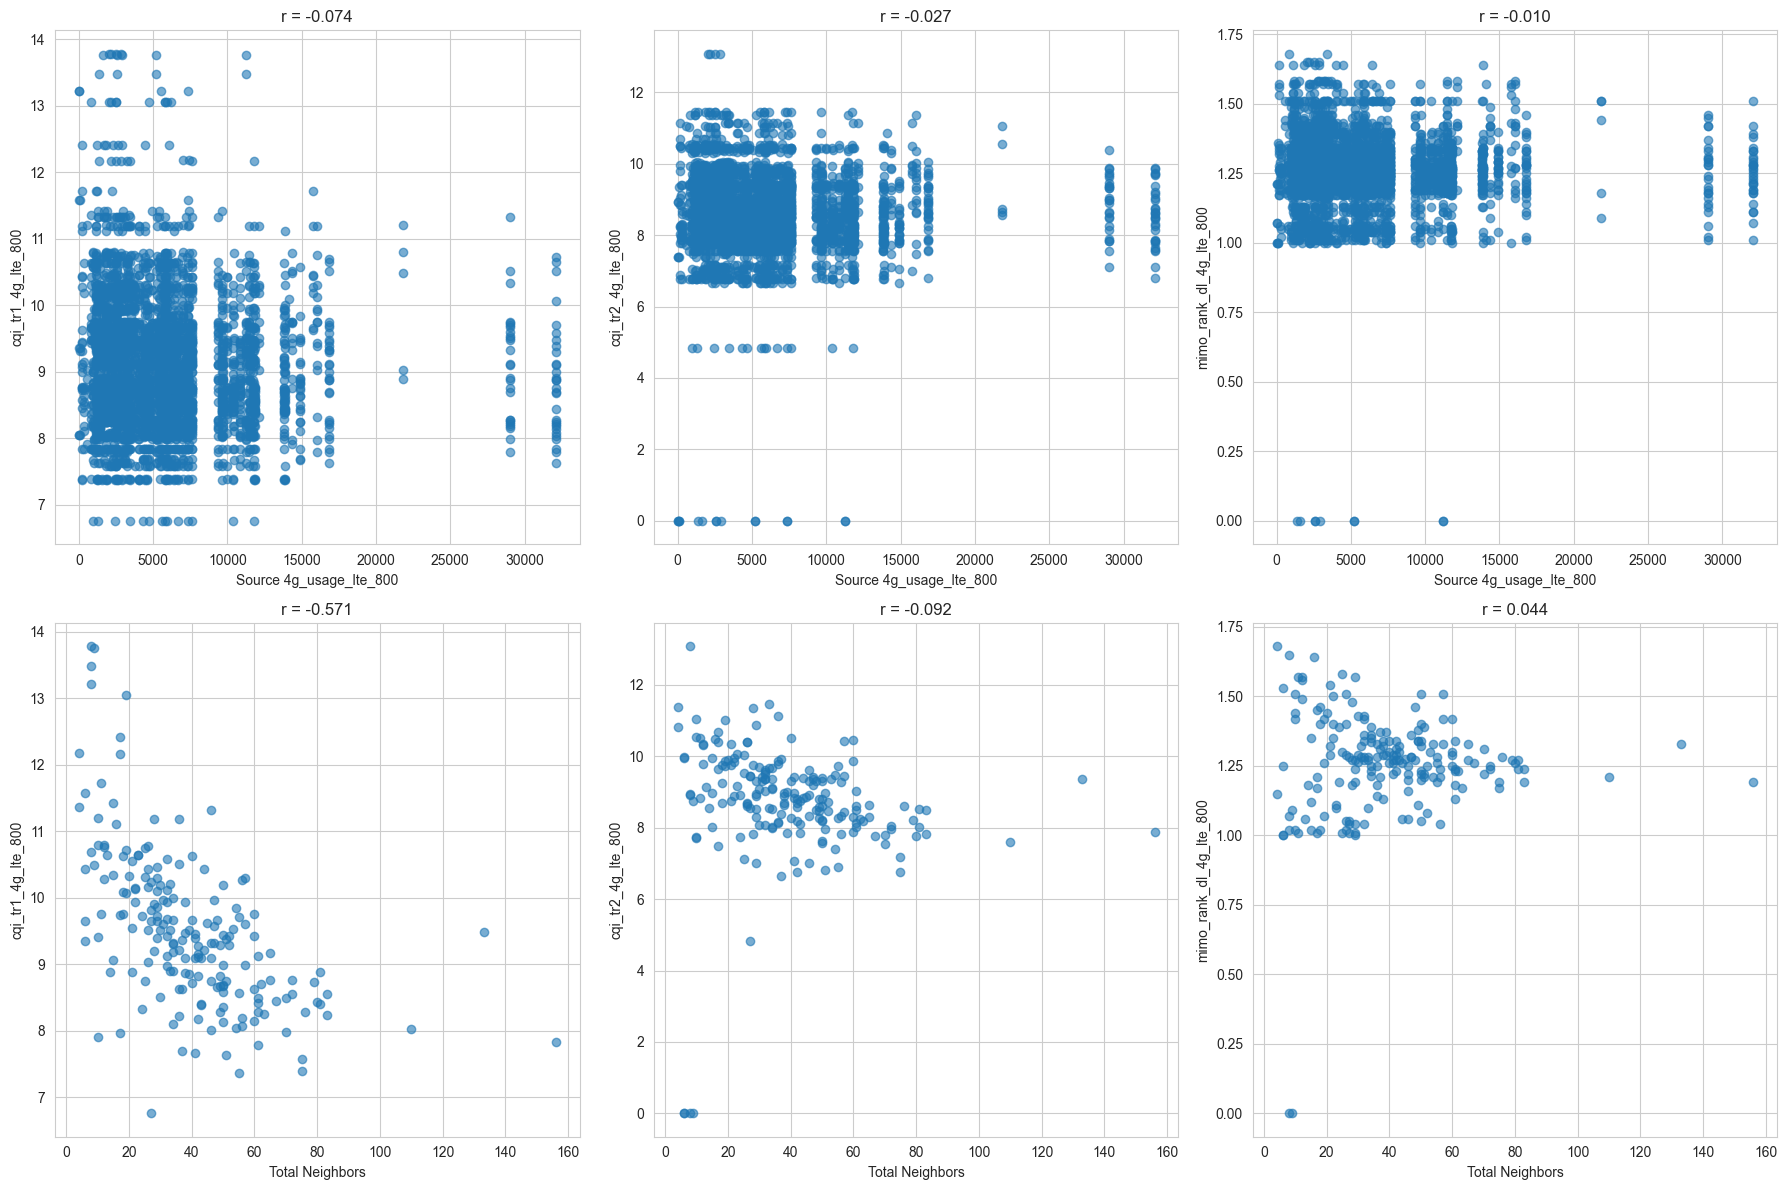

In [14]:
# 6. VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 6.1. Source usage vs target quality
for i, target_metric in enumerate(TARGET_METRICS):
    corr_col = f"target_{target_metric.split('_')[0]}_{target_metric.split('_')[1]}"
    axes[0, i].scatter(edge_list["source_" + SOURCE_METRIC], edge_list[corr_col], alpha=0.6)
    axes[0, i].set_xlabel("Source " + SOURCE_METRIC)
    axes[0, i].set_ylabel(target_metric)
    axes[0, i].set_title(f"r = {correlations[target_metric][0]:.3f}")

# 6.2. Neighbor count vs target quality
for i, target_metric in enumerate(TARGET_METRICS):
    axes[1, i].scatter(neighbor_analysis["total_neighbors"], neighbor_analysis[target_metric], alpha=0.6)
    axes[1, i].set_xlabel("Total Neighbors")
    axes[1, i].set_ylabel(target_metric)
    axes[1, i].set_title(f"r = {neighbor_correlations[target_metric][0]:.3f}")

plt.tight_layout()
plt.show()

Analyzed 193 cells with neighbor CQI data


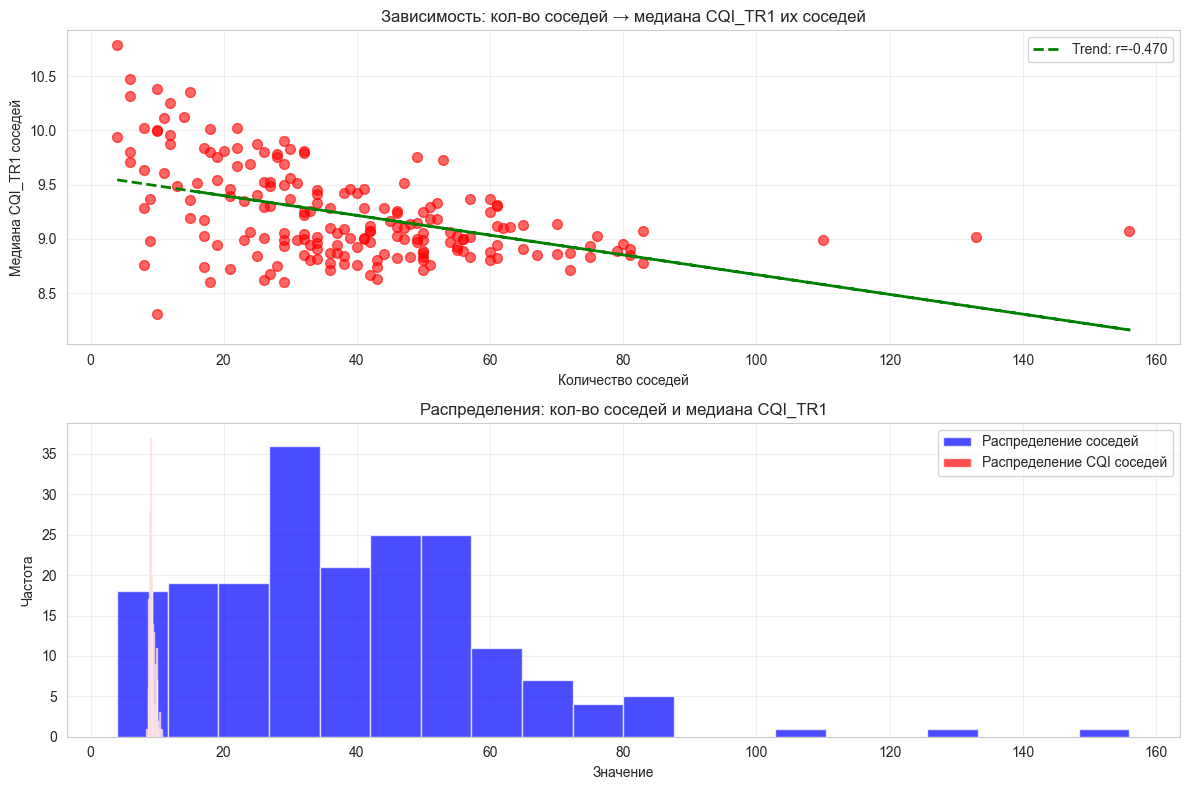


Корреляция: количество соседей vs медиана CQI_TR1 соседей = -0.4698
Количество проанализированных клеток: 193
Диапазон соседей: 4 - 156
Диапазон CQI: 8.31 - 10.79


In [26]:
# ---------- ВИЗУАЛИЗАЦИЯ ЛИНЕЙНОГО ГРАФИКА: кол-во соседей vs медиана CQI_TR1 соседей ----------

# 1. Создаём таблицу: для каждой клетки = её кол-во соседей + медиана CQI её соседей
neighbor_cqi_medians = []

for cell in neighbor_df.index:
    # Находим соседей этой клетки
    neighbors = set(edge_list[edge_list["target"] == cell]["source"].unique()) | \
                set(edge_list[edge_list["source"] == cell]["target"].unique())

    # Медиана CQI_TR1 всех соседей этой клетки (по всему времени)
    neighbor_cqi_values = df_kpi[
        df_kpi["cell"].isin(neighbors) &
        df_kpi["cqi_tr1_4g_lte_800"].notna()
    ]["cqi_tr1_4g_lte_800"]

    if len(neighbor_cqi_values) > 0:
        median_neighbor_cqi = neighbor_cqi_values.median()
        neighbor_cqi_medians.append({
            "cell": cell,
            "total_neighbors": neighbor_df.loc[cell, "total_neighbors"],
            "median_neighbor_cqi_tr1": median_neighbor_cqi
        })

neighbor_cqi_df = pd.DataFrame(neighbor_cqi_medians).dropna()

print(f"Analyzed {len(neighbor_cqi_df)} cells with neighbor CQI data")

# 2. Линейный график
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
scatter = plt.scatter(neighbor_cqi_df["total_neighbors"],
                     neighbor_cqi_df["median_neighbor_cqi_tr1"],
                     alpha=0.6, s=50, c='red')
plt.xlabel("Количество соседей")
plt.ylabel("Медиана CQI_TR1 соседей")
plt.title("Зависимость: кол-во соседей → медиана CQI_TR1 их соседей")
plt.grid(True, alpha=0.3)

# Линия тренда
z = np.polyfit(neighbor_cqi_df["total_neighbors"], neighbor_cqi_df["median_neighbor_cqi_tr1"], 1)
p = np.poly1d(z)
plt.plot(neighbor_cqi_df["total_neighbors"], p(neighbor_cqi_df["total_neighbors"]),
         "g--", linewidth=2, label=f"Trend: r={np.corrcoef(neighbor_cqi_df['total_neighbors'], neighbor_cqi_df['median_neighbor_cqi_tr1'])[0,1]:.3f}")
plt.legend()

# 3. Гистограммы для контекста
plt.subplot(2, 1, 2)
plt.hist(neighbor_cqi_df["total_neighbors"], bins=20, alpha=0.7, label="Распределение соседей", color='blue')
plt.hist(neighbor_cqi_df["median_neighbor_cqi_tr1"], bins=20, alpha=0.7, label="Распределение CQI соседей", color='red')
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.title("Распределения: кол-во соседей и медиана CQI_TR1")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Статистика
corr_final = np.corrcoef(neighbor_cqi_df["total_neighbors"], neighbor_cqi_df["median_neighbor_cqi_tr1"])[0,1]
print(f"\nКорреляция: количество соседей vs медиана CQI_TR1 соседей = {corr_final:.4f}")
print(f"Количество проанализированных клеток: {len(neighbor_cqi_df)}")
print(f"Диапазон соседей: {neighbor_cqi_df['total_neighbors'].min():.0f} - {neighbor_cqi_df['total_neighbors'].max():.0f}")
print(f"Диапазон CQI: {neighbor_cqi_df['median_neighbor_cqi_tr1'].min():.2f} - {neighbor_cqi_df['median_neighbor_cqi_tr1'].max():.2f}")


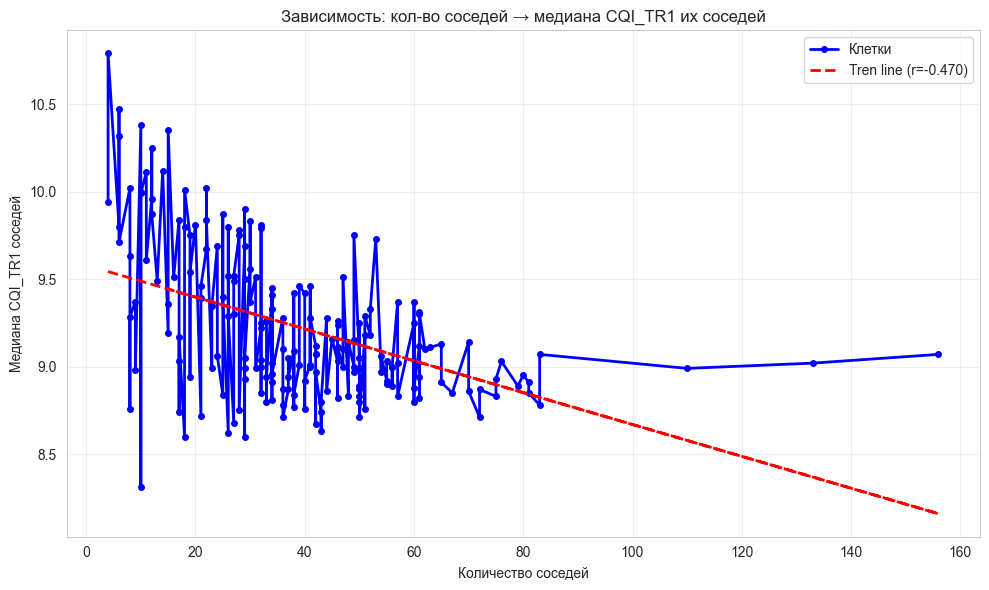

Клеток проанализировано: 193
Корреляция: r = -0.4698
Диапазон соседей: 4 - 156
Диапазон CQI соседей: 8.31 - 10.79


In [27]:
# ---------- ЛИНЕЙНЫЙ ГРАФИК: кол-во соседей vs медиана CQI_TR1 соседей ----------

# 1. Таблица: каждая клетка = её кол-во соседей + медиана CQI её соседей
data_for_plot = []

for cell in neighbor_df.index:
    # Все соседи клетки (входящие + исходящие)
    incoming = edge_list[edge_list["target"] == cell]["source"].unique()
    outgoing = edge_list[edge_list["source"] == cell]["target"].unique()
    all_neighbors = list(set(incoming) | set(outgoing))

    # Медиана CQI_TR1 всех соседей по ВСЕМУ времени
    neighbors_cqi = df_kpi[
        (df_kpi["cell"].isin(all_neighbors)) &
        df_kpi["cqi_tr1_4g_lte_800"].notna()
    ]["cqi_tr1_4g_lte_800"]

    if len(neighbors_cqi) > 0:
        median_cqi_neighbors = neighbors_cqi.median()
        data_for_plot.append({
            "cell": cell,
            "n_neighbors": neighbor_df.loc[cell, "total_neighbors"],
            "median_cqi_neighbors": median_cqi_neighbors
        })

plot_df = pd.DataFrame(data_for_plot).dropna()

# 2. ПРОСТОЙ LINE PLOT
plt.figure(figsize=(10, 6))

# Сортируем по количеству соседей для line plot
plot_df_sorted = plot_df.sort_values("n_neighbors")

plt.plot(plot_df_sorted["n_neighbors"], plot_df_sorted["median_cqi_neighbors"],
         'b-o', linewidth=2, markersize=4, label="Клетки")
plt.xlabel("Количество соседей")
plt.ylabel("Медиана CQI_TR1 соседей")
plt.title("Зависимость: кол-во соседей → медиана CQI_TR1 их соседей")
plt.grid(True, alpha=0.3)
plt.legend()

# Линия тренда
z = np.polyfit(plot_df["n_neighbors"], plot_df["median_cqi_neighbors"], 1)
p = np.poly1d(z)
plt.plot(plot_df["n_neighbors"], p(plot_df["n_neighbors"]), "r--",
         linewidth=2, label=f"Tren line (r={np.corrcoef(plot_df['n_neighbors'], plot_df['median_cqi_neighbors'])[0,1]:.3f})")
plt.legend()

plt.tight_layout()
plt.show()

# Статистика
print(f"Клеток проанализировано: {len(plot_df)}")
print(f"Корреляция: r = {np.corrcoef(plot_df['n_neighbors'], plot_df['median_cqi_neighbors'])[0,1]:.4f}")
print(f"Диапазон соседей: {plot_df['n_neighbors'].min():.0f} - {plot_df['n_neighbors'].max():.0f}")
print(f"Диапазон CQI соседей: {plot_df['median_cqi_neighbors'].min():.2f} - {plot_df['median_cqi_neighbors'].max():.2f}")


Клеток после лимита 90 соседей: 190 (было 193)


C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\703481266.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in plot_df_limited.groupby('neighbor_group')
C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\703481266.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True)


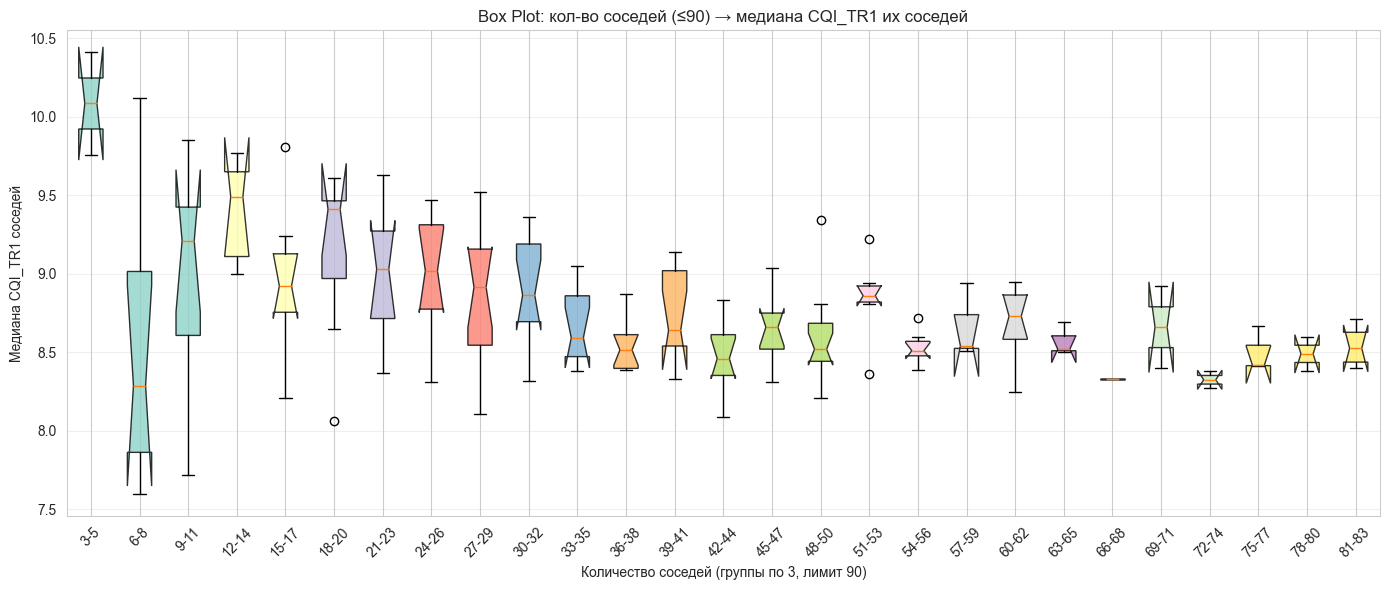


СТАТИСТИКА ПО ГРУППАМ (лимит 90):
                count  median    mean    std
neighbor_group                              
[3, 6)              2  10.085  10.085  0.460
[6, 9)              8   8.288   8.513  0.880
[9, 12)             8   9.210   8.975  0.723
[12, 15)            5   9.490   9.404  0.336
[15, 18)            8   8.922   8.949  0.471
[18, 21)            7   9.410   9.136  0.568
[21, 24)            8   9.030   8.996  0.420
[24, 27)           10   9.020   8.991  0.379
[27, 30)           14   8.915   8.836  0.429
[30, 33)           12   8.865   8.902  0.346
[33, 36)           10   8.592   8.660  0.237
[36, 39)           12   8.515   8.540  0.155
[39, 42)            9   8.640   8.746  0.291
[42, 45)           10   8.460   8.455  0.224
[45, 48)            9   8.660   8.674  0.226
[48, 51)           14   8.520   8.580  0.275
[51, 54)            6   8.860   8.842  0.278
[54, 57)            8   8.510   8.528  0.102
[57, 60)            3   8.540   8.663  0.240
[60, 63)           1

C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\703481266.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = plot_df_limited.groupby('neighbor_group')['median_cqi_neighbors'].agg(


In [30]:
# ---------- BOX-PLOT: кол-во соседей (0-90) vs медиана CQI_TR1 соседей ----------

# ЛИМИТ 90 соседей
plot_df_limited = plot_df[plot_df['n_neighbors'] <= 90].copy()
print(f"Клеток после лимита 90 соседей: {len(plot_df_limited)} (было {len(plot_df)})")

if len(plot_df_limited) < 10:
    print("Недостаточно данных для box plot")
else:
    # Создаём категории по 3 соседа (0-2, 3-5, 6-8, ..., 87-90)
    plot_df_limited['neighbor_group'] = pd.cut(
        plot_df_limited['n_neighbors'],
        bins=range(0, 91, 3),  # шаг 3 до 90
        right=False,
        include_lowest=True
    )

    # Box plot только с данными <=90
    plt.figure(figsize=(14, 6))

    box_data = [group['median_cqi_neighbors'].values
                for name, group in plot_df_limited.groupby('neighbor_group')
                if len(group) > 0]
    box_labels = [f"{int(g.left)}-{int(g.right-1)}"
                  for g in plot_df_limited['neighbor_group'].cat.categories
                  if len(plot_df_limited[plot_df_limited['neighbor_group'] == g]) > 0]

    bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True)

    plt.xlabel("Количество соседей (группы по 3, лимит 90)")
    plt.ylabel("Медиана CQI_TR1 соседей")
    plt.title("Box Plot: кол-во соседей (≤90) → медиана CQI_TR1 их соседей")
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)

    # Цвета для ящиков
    colors = plt.cm.Set3(np.linspace(0, 1, len(box_data)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    plt.tight_layout()
    plt.show()

    # Статистика по группам (только <=90)
    group_stats = plot_df_limited.groupby('neighbor_group')['median_cqi_neighbors'].agg(
        ['count', 'median', 'mean', 'std']
    ).round(3)
    print("\nСТАТИСТИКА ПО ГРУППАМ (лимит 90):")
    print(group_stats[group_stats['count'] > 0])

    print(f"\nКорреляция (0-90 соседей): r = {np.corrcoef(plot_df_limited['n_neighbors'], plot_df_limited['median_cqi_neighbors'])[0,1]:.4f}")


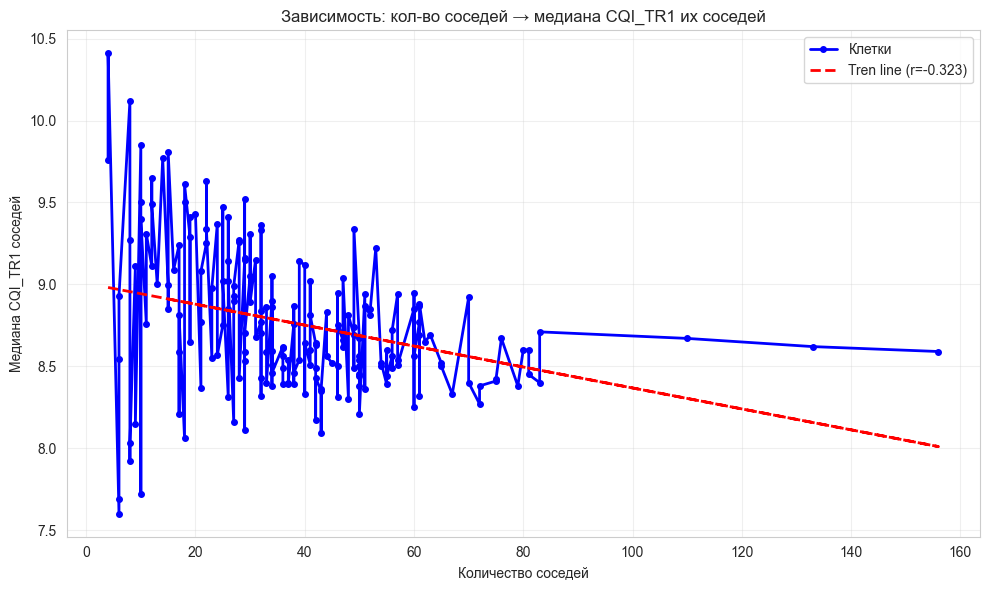

Клеток проанализировано: 193
Корреляция: r = -0.3228
Диапазон соседей: 4 - 156
Диапазон CQ2 соседей: 7.60 - 10.41


In [28]:
# ---------- ЛИНЕЙНЫЙ ГРАФИК: кол-во соседей vs медиана CQI_TR1 соседей ----------

# 1. Таблица: каждая клетка = её кол-во соседей + медиана CQI её соседей
data_for_plot = []

for cell in neighbor_df.index:
    # Все соседи клетки (входящие + исходящие)
    incoming = edge_list[edge_list["target"] == cell]["source"].unique()
    outgoing = edge_list[edge_list["source"] == cell]["target"].unique()
    all_neighbors = list(set(incoming) | set(outgoing))

    # Медиана CQI_TR1 всех соседей по ВСЕМУ времени
    neighbors_cqi = df_kpi[
        (df_kpi["cell"].isin(all_neighbors)) &
        df_kpi["cqi_tr2_4g_lte_800"].notna()
    ]["cqi_tr2_4g_lte_800"]

    if len(neighbors_cqi) > 0:
        median_cqi_neighbors = neighbors_cqi.median()
        data_for_plot.append({
            "cell": cell,
            "n_neighbors": neighbor_df.loc[cell, "total_neighbors"],
            "median_cqi_neighbors": median_cqi_neighbors
        })

plot_df = pd.DataFrame(data_for_plot).dropna()

# 2. ПРОСТОЙ LINE PLOT
plt.figure(figsize=(10, 6))

# Сортируем по количеству соседей для line plot
plot_df_sorted = plot_df.sort_values("n_neighbors")

plt.plot(plot_df_sorted["n_neighbors"], plot_df_sorted["median_cqi_neighbors"],
         'b-o', linewidth=2, markersize=4, label="Клетки")
plt.xlabel("Количество соседей")
plt.ylabel("Медиана CQI_TR1 соседей")
plt.title("Зависимость: кол-во соседей → медиана CQI_TR1 их соседей")
plt.grid(True, alpha=0.3)
plt.legend()

# Линия тренда
z = np.polyfit(plot_df["n_neighbors"], plot_df["median_cqi_neighbors"], 1)
p = np.poly1d(z)
plt.plot(plot_df["n_neighbors"], p(plot_df["n_neighbors"]), "r--",
         linewidth=2, label=f"Tren line (r={np.corrcoef(plot_df['n_neighbors'], plot_df['median_cqi_neighbors'])[0,1]:.3f})")
plt.legend()

plt.tight_layout()
plt.show()

# Статистика
print(f"Клеток проанализировано: {len(plot_df)}")
print(f"Корреляция: r = {np.corrcoef(plot_df['n_neighbors'], plot_df['median_cqi_neighbors'])[0,1]:.4f}")
print(f"Диапазон соседей: {plot_df['n_neighbors'].min():.0f} - {plot_df['n_neighbors'].max():.0f}")
print(f"Диапазон CQ2 соседей: {plot_df['median_cqi_neighbors'].min():.2f} - {plot_df['median_cqi_neighbors'].max():.2f}")


C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\2523408019.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  [group['median_cqi_neighbors'].values for name, group in plot_df.groupby('neighbor_group')],
C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\2523408019.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(


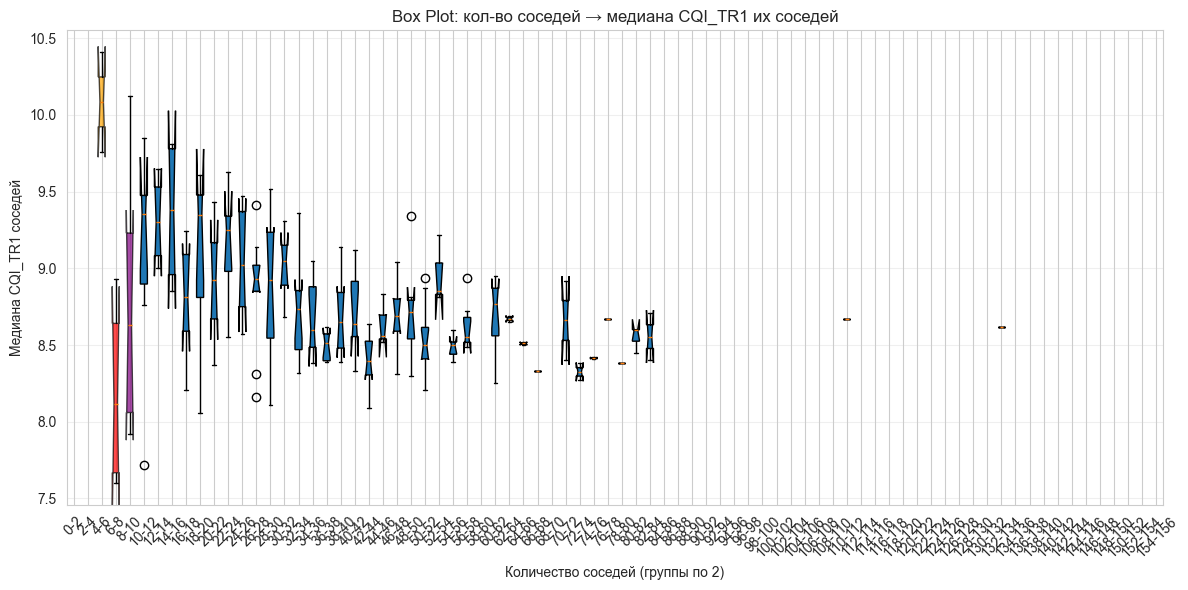

СТАТИСТИКА ПО ГРУППАМ СОСЕДЕЙ:
                count  median    mean    std
neighbor_group                              
[0, 2)              0     NaN     NaN    NaN
[2, 4)              0     NaN     NaN    NaN
[4, 6)              2  10.085  10.085  0.460
[6, 8)              4   8.118   8.191  0.651
[8, 10)             6   8.630   8.767  0.877
...               ...     ...     ...    ...
[146, 148)          0     NaN     NaN    NaN
[148, 150)          0     NaN     NaN    NaN
[150, 152)          0     NaN     NaN    NaN
[152, 154)          0     NaN     NaN    NaN
[154, 156)          0     NaN     NaN    NaN

[78 rows x 4 columns]

Общая корреляция: r = -0.3228


C:\Users\sirad\AppData\Local\Temp\ipykernel_21832\2523408019.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = plot_df.groupby('neighbor_group')['median_cqi_neighbors'].agg(['count', 'median', 'mean', 'std']).round(3)


In [29]:
# ---------- BOX-PLOT: кол-во соседей vs медиана CQI_TR1 соседей ----------

# Используем уже готовую таблицу plot_df из предыдущего блока
# Если нет - пересоздаём минимально
if 'plot_df' not in locals():
    data_for_plot = []
    for cell in neighbor_df.index:
        incoming = edge_list[edge_list["target"] == cell]["source"].unique()
        outgoing = edge_list[edge_list["source"] == cell]["target"].unique()
        all_neighbors = list(set(incoming) | set(outgoing))

        neighbors_cqi = df_kpi[
            (df_kpi["cell"].isin(all_neighbors)) &
            df_kpi["cqi_tr1_4g_lte_800"].notna()
        ]["cqi_tr1_4g_lte_800"]

        if len(neighbors_cqi) > 0:
            data_for_plot.append({
                "n_neighbors": neighbor_df.loc[cell, "total_neighbors"],
                "median_cqi_neighbors": neighbors_cqi.median()
            })
    plot_df = pd.DataFrame(data_for_plot).dropna()

# Создаём категории по количеству соседей (для box plot)
plot_df['neighbor_group'] = pd.cut(plot_df['n_neighbors'],
                                  bins=range(0, int(plot_df['n_neighbors'].max())+2, 2),
                                  right=False, include_lowest=True)

# Box plot
plt.figure(figsize=(12, 6))

# Основной box plot
box_plot = plt.boxplot(
    [group['median_cqi_neighbors'].values for name, group in plot_df.groupby('neighbor_group')],
    labels=[f"{g.left}-{g.right}" for g in plot_df['neighbor_group'].cat.categories],
    patch_artist=True,
    notch=True
)

plt.xlabel("Количество соседей (группы по 2)")
plt.ylabel("Медиана CQI_TR1 соседей")
plt.title("Box Plot: кол-во соседей → медиана CQI_TR1 их соседей")
plt.grid(True, alpha=0.3, axis='y')

# Окраска ящиков
colors = ['lightblue', 'lightgreen', 'orange', 'red', 'purple']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Статистика по группам
print("СТАТИСТИКА ПО ГРУППАМ СОСЕДЕЙ:")
group_stats = plot_df.groupby('neighbor_group')['median_cqi_neighbors'].agg(['count', 'median', 'mean', 'std']).round(3)
print(group_stats)

print(f"\nОбщая корреляция: r = {np.corrcoef(plot_df['n_neighbors'], plot_df['median_cqi_neighbors'])[0,1]:.4f}")
